ВАРИАНТ 1

In [154]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
#оценка эффективности результата предположения.
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

Практический пример использования случайного леса в задачах
классификации

In [155]:
data1 = pd.read_csv('task11.csv')
# data2 = pd.read_csv('task21.csv')
features = data1.drop(columns=['target'])
label = data1['target']
features

,x1,x2
0,9.249743,12.797165
1,26.118513,13.936663
2,8.696962,11.116652
3,21.614879,6.138127
4,11.247285,12.849175
...,...,...
395,24.402084,10.749480
396,9.384956,12.256265
397,25.091591,10.087860
398,12.844631,10.026040


In [156]:
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.3,
random_state = 42)

обучаем модель с помощью алгоритма классификации RandomForestClassifier.

In [157]:
clf = RandomForestClassifier(random_state=42)
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [158]:
y_pred = clf.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1])

оценка эффективности результата предположения

In [159]:
result = accuracy_score(y_test,y_pred)
print("Accuracy:",result)

Accuracy: 0.9916666666666667


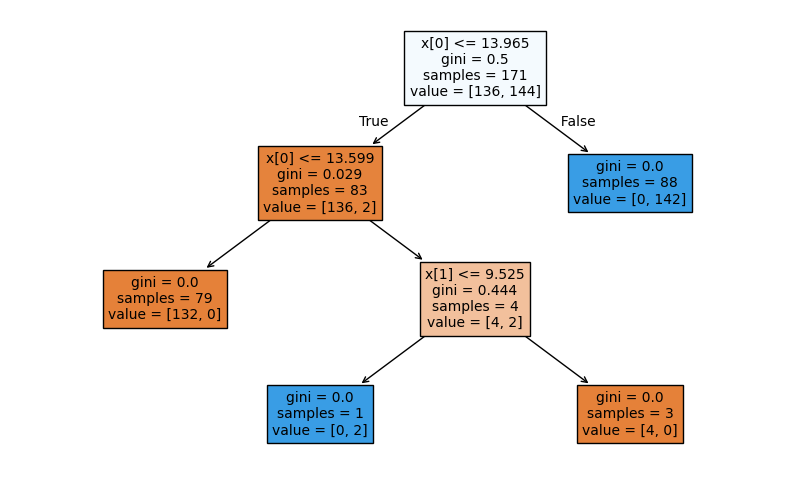

In [160]:
plt.figure(figsize=(10,6))
plot_tree(clf.estimators_[3], filled=True, fontsize=10)
#estimators_[3] равное 3, отвечает за
# то, какое дерево из леса вы хотите отобразить.
plt.savefig('random_tree.png')
plt.show()


Чтобы отобразить все деревья можно воспользоваться циклом:

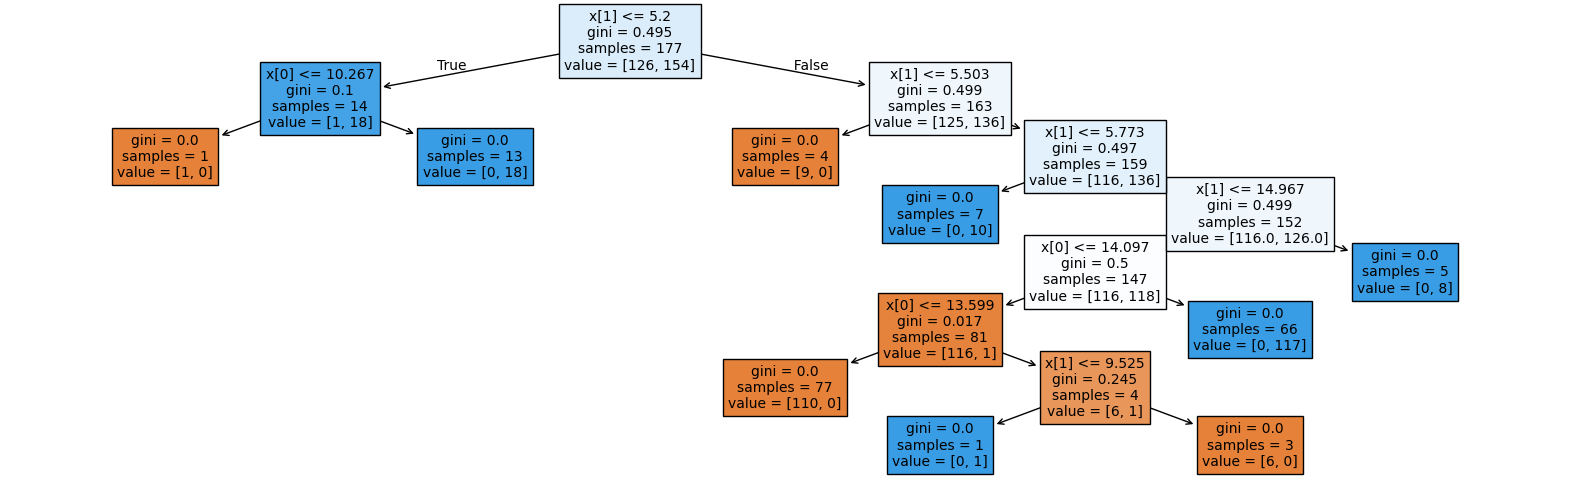

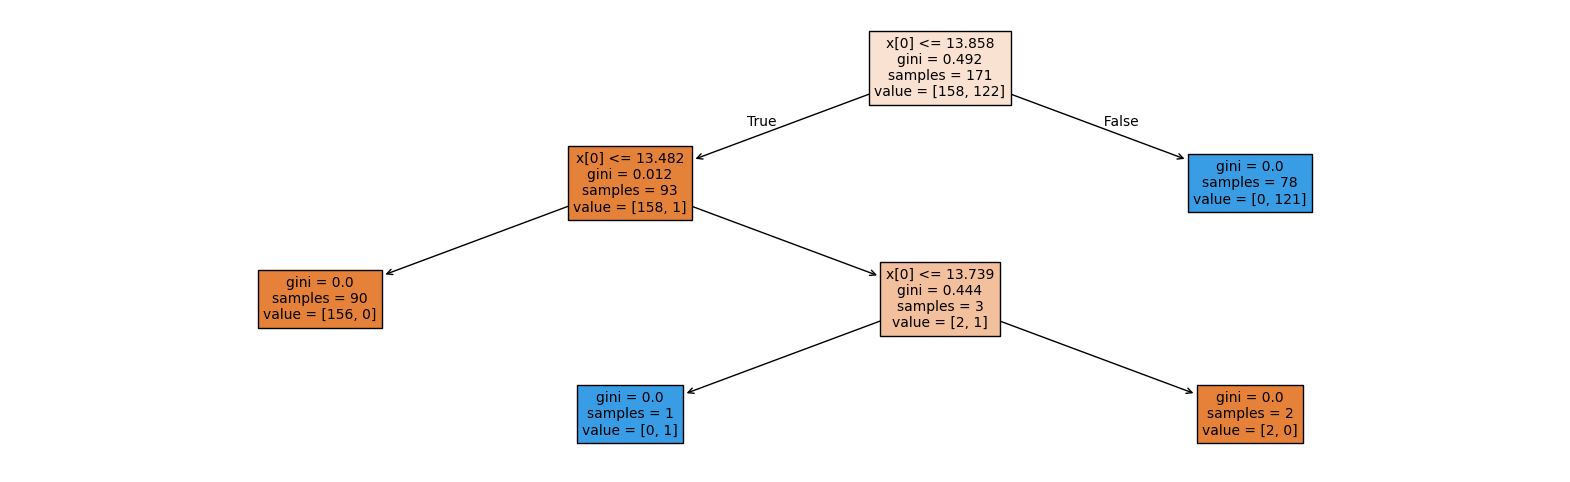

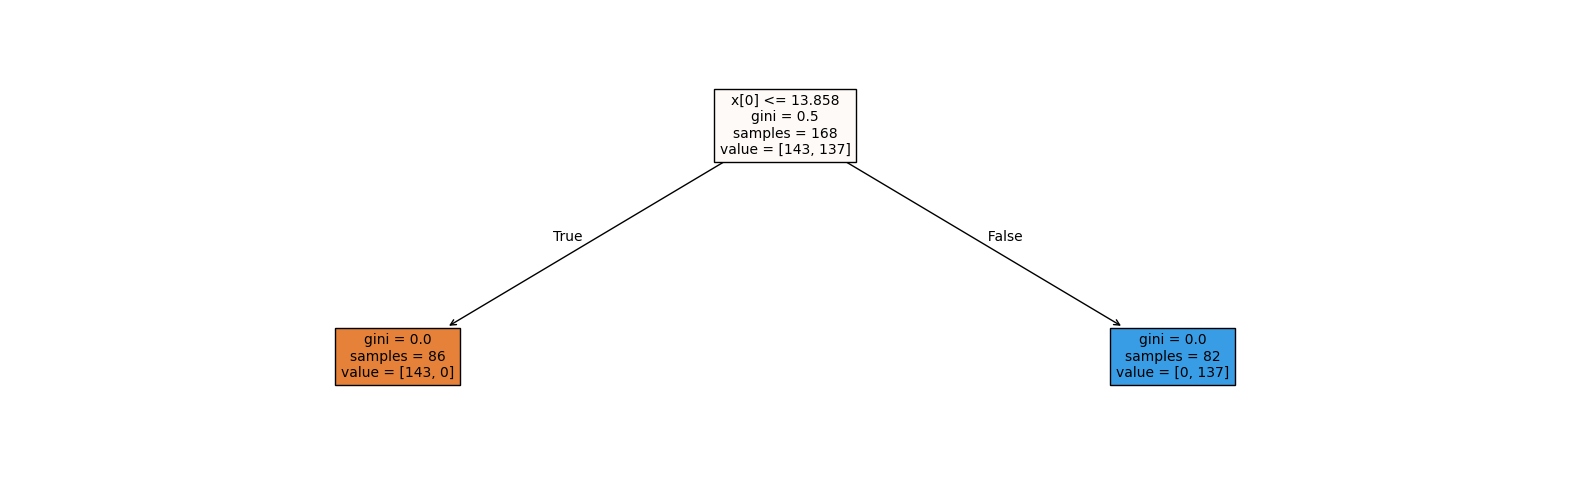

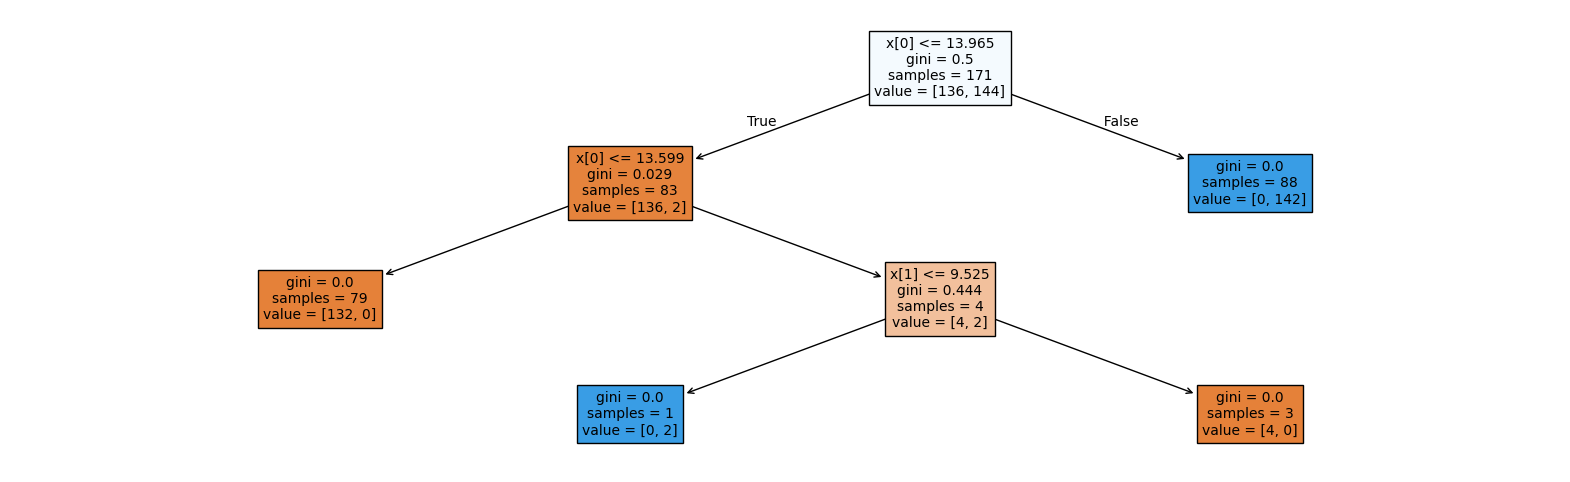

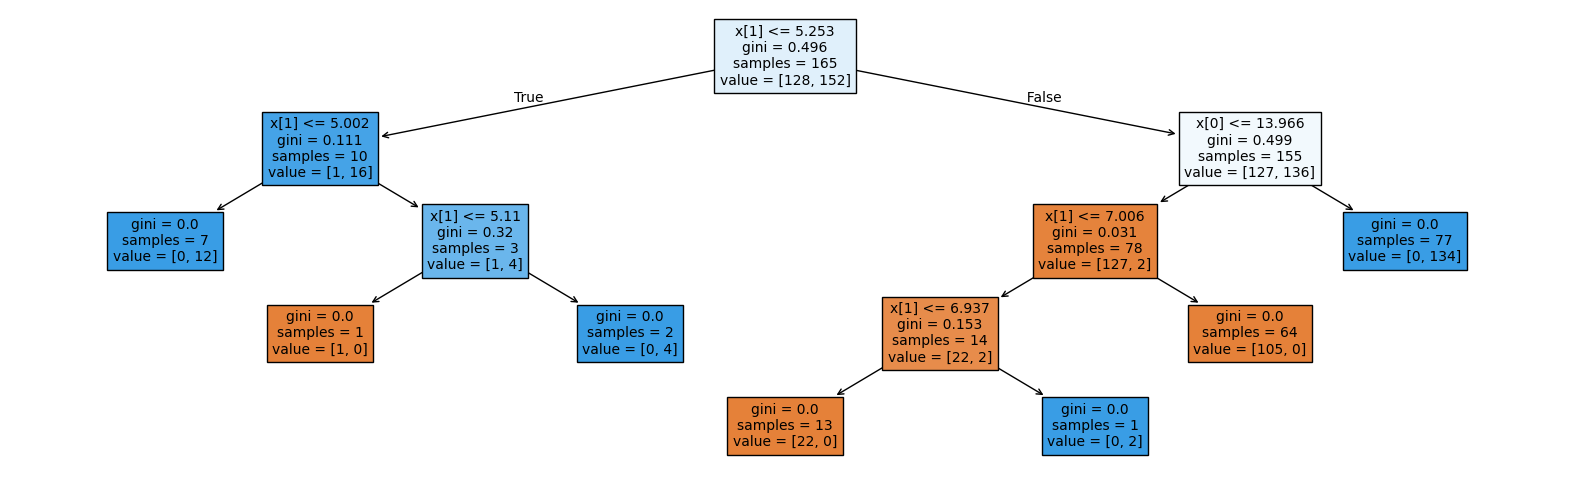

In [161]:
for index in range(0, 5):
    plt.figure(figsize=(20,6))
    plot_tree(clf.estimators_[index], filled=True , fontsize=10)
    plt.show()

использования GridSearch для нахождения
оптимальных значений гиперпараметров

In [162]:
from sklearn.model_selection import GridSearchCV


In [163]:
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.25, random_state = 42)


In [164]:
parametrs = {'n_estimators': range(10, 51, 10), #число деревьев в лесу, оно будет изменяться от 10 до 50 с шагом 10
'max_depth': range(1, 13, 2), #глубина дерева, она будет изменяться от 1 до 12 с шагом 2
'min_samples_leaf': range(1, 8), #минимальное число образцов в листах, оно будет изменяться от 1 до 7 с шагом 1 (берется по умолчанию)
'min_samples_split': range(2, 10, 2)} #минимальное число образцов для разделения, оно будет изменяться от 2 до 9 с шагом 2

создаем словарь, который будет содержать значения параметров.

In [165]:
clf = RandomForestClassifier()
grid = GridSearchCV(clf, parametrs, cv=5)

In [166]:
grid.fit(x_train, y_train)
print(grid.best_params_)

{'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 20}


In [167]:
y_pred = grid.predict(x_test)
y_pred


array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1])

In [168]:
result = accuracy_score(y_test,y_pred)
print("Accuracy:",result)

Accuracy: 0.99


использования RandomizedSearchCV для нахождения
оптимальных значений гиперпараметров 

In [169]:
from sklearn.model_selection import RandomizedSearchCV

In [170]:
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.25, random_state = 42)


In [171]:
parametrs = {'n_estimators': range(10, 51, 10), #число деревьев в лесу, оно будет изменяться от 10 до 50 с шагом 10
'max_depth': range(1, 13, 2), #глубина дерева, она будет изменяться от 1 до 12 с шагом 2
'min_samples_leaf': range(1, 8), #минимальное число образцов в листах, оно будет изменяться от 1 до 7 с шагом 1 (берется по умолчанию)
'min_samples_split': range(2, 10, 2)} #минимальное число образцов для разделения, оно будет изменяться от 2 до 9 с шагом 2

In [172]:
clf = RandomForestClassifier()
rand = RandomizedSearchCV(clf, parametrs, cv=5)
rand.fit(x_train, y_train)
print(rand.best_params_)

{'n_estimators': 30, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 7}


In [173]:
y_pred = rand.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1])

In [174]:
result = accuracy_score(y_test,y_pred)
print("Accuracy:",result)

Accuracy: 0.99


Практический пример использования случайного леса в задачах регрессии на примере данных из практики 2

In [175]:

y = pd.Series([55, 80, 55, 83, 86, 107, 85, 50, 75, 50, 95, 40, 100, 40, 60], name="y")
x1 = pd.Series([14, 11, 14, 8, 8, 7, 7, 14, 7, 17, 7, 14, 6, 18, 12], name="x1")
x2 = pd.Series([100, 150, 195, 118, 77, 100, 100, 180, 79, 90, 100, 184, 76, 83, 100], name="x2")

df = pd.concat([x1, x2], axis=1)
# Разделение на выборки
X_train, X_test, Y_train, Y_test = train_test_split(
    df, y, 
    test_size=0.25, 
    random_state=42
)
print(X_train.shape, Y_train.shape)


(11, 2) (11,)


обучаем модель с помощью алгоритма регрессии

In [176]:
regressor = RandomForestRegressor(n_estimators=20, random_state=42)
regressor.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [177]:
Y_pred = regressor.predict(X_test)

In [178]:
print(mean_absolute_error(Y_test, Y_pred))

14.3


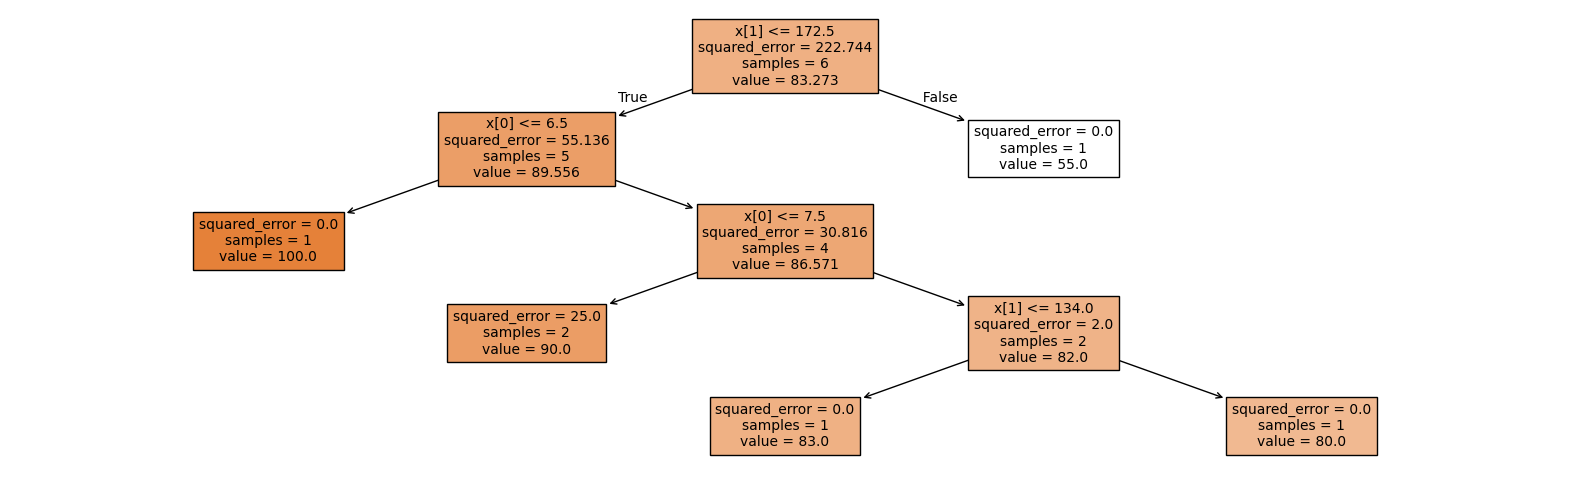

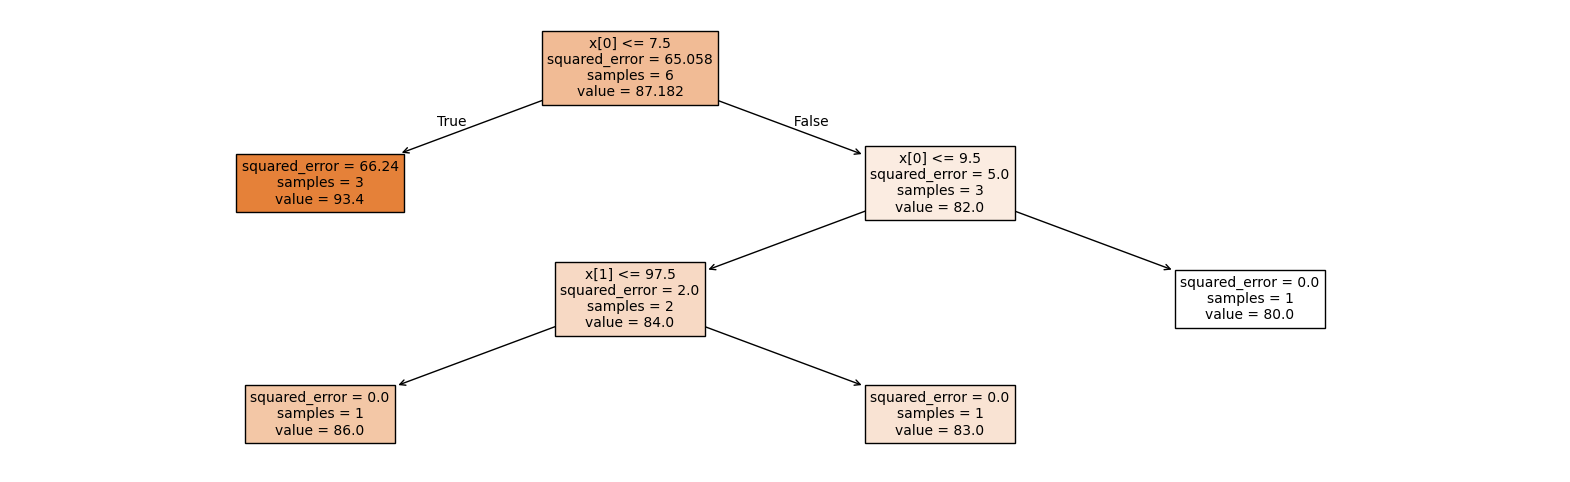

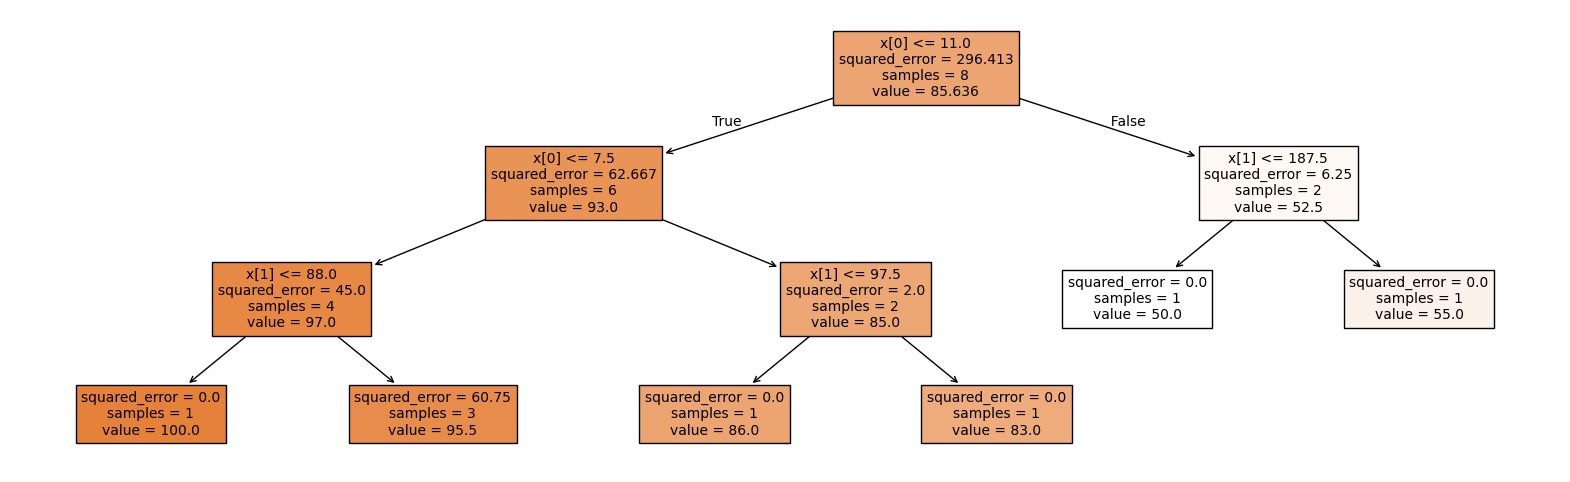

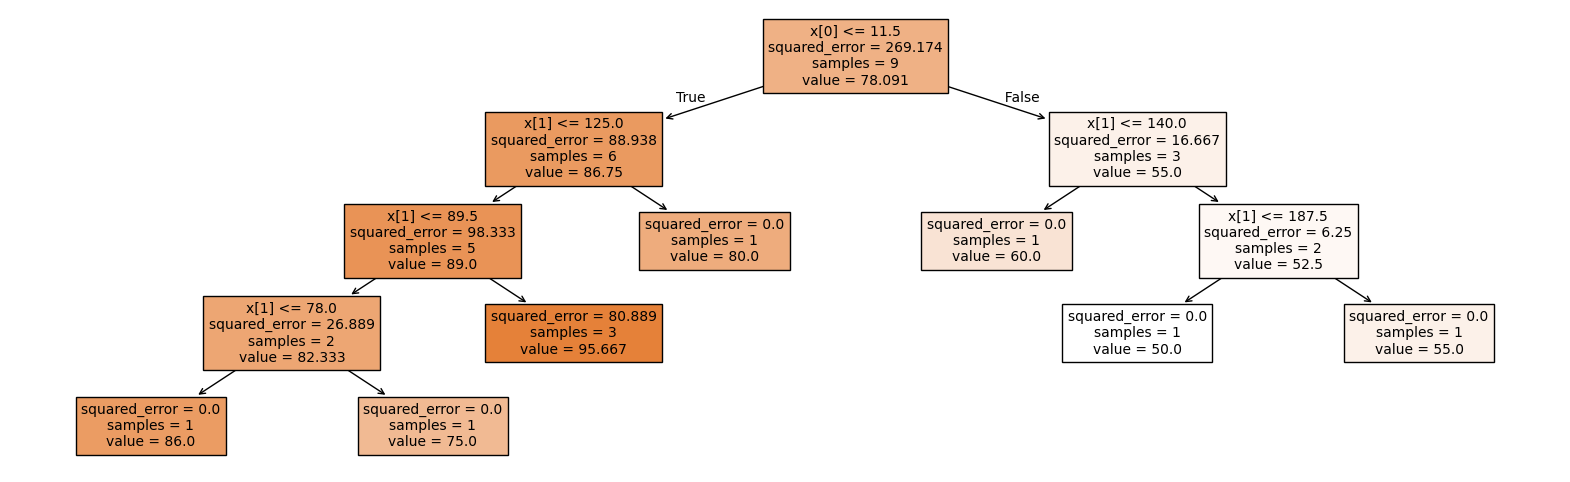

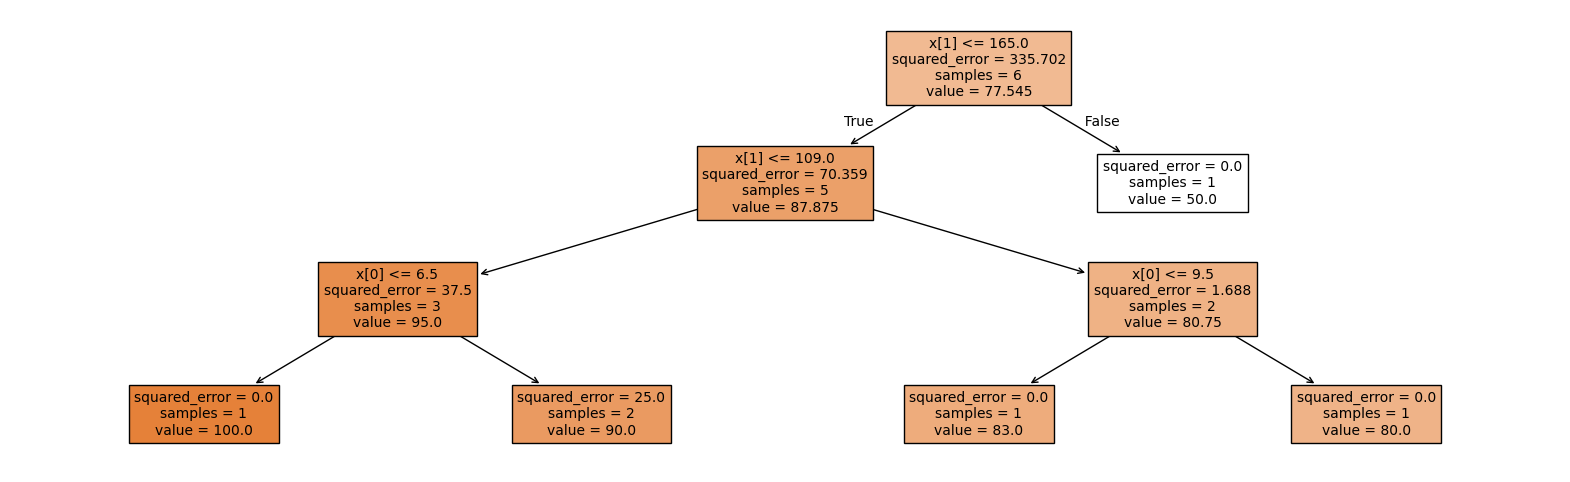

In [184]:
for index in range(0, 5):
    plt.figure(figsize=(20,6))
    plot_tree(regressor.estimators_[index], filled=True , fontsize=10)
    plt.show()